# 03 - Naive OLS

Simple regression of traffic fatalities on legalization status with no fixed effects. Establishes the biased baseline before adding design.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

FARS_FILE = "fars_state_year.parquet"
CDC_FILE  = "cdc_state_year.parquet"

# Load FARS panel
if not (DATA_DIR / FARS_FILE).exists():
    raise FileNotFoundError(
        f"{FARS_FILE} not found. Run:\n"
        "  python scripts/download_fars.py\n"
        "  python src/build_fars_panel.py"
    )
fars = pd.read_parquet(DATA_DIR / FARS_FILE)
leg  = pd.read_csv("../data/codebooks/state_legalization_dates.csv")
print(f"FARS panel: {fars.shape}  |  States: {fars['state'].nunique()}  |  Years: {sorted(fars['year'].dropna().unique()[:3])}...{sorted(fars['year'].dropna().unique()[-3:])}")

FARS panel: (676, 11)  |  States: 51  |  Years: [np.int64(2010), np.int64(2011), np.int64(2012)]...[np.int64(2020), np.int64(2021), np.int64(2022)]


In [2]:
import statsmodels.formula.api as smf

In [3]:
primary = "total_fatalities_per_100k" if "total_fatalities_per_100k" in fars.columns else "total_fatalities"

# Add treated indicator
# drop col if already present to avoid _x/_y suffix from merge
_leg_merge = leg[['state','retail_sales_year']]
fars_reg = fars.drop(columns=[c for c in ['retail_sales_year'] if c in fars.columns]).merge(_leg_merge, on='state', how='left')
fars_reg['ever_treated'] = fars_reg['retail_sales_year'].notna().astype(int)
fars_reg['post'] = (fars_reg['retail_sales_year'].notna() & (fars_reg['year'] >= fars_reg['retail_sales_year'])).astype(int)
fars_reg['did'] = fars_reg['ever_treated'] * fars_reg['post']

## Model 1 - Simple cross-sectional (most biased)

In [4]:
m1 = smf.ols(f"{primary} ~ ever_treated", data=fars_reg).fit(cov_type='HC3')
print(f"Treated vs never-treated: β = {m1.params['ever_treated']:.4f}")
print("This is pure selection — treated states differ in many ways from control states.")

Treated vs never-treated: β = -3.4463
This is pure selection — treated states differ in many ways from control states.


## Model 2 - Before/after for treated states only (no controls)

In [5]:
m2 = smf.ols(f"{primary} ~ post", data=fars_reg[fars_reg['ever_treated']==1]).fit(cov_type='HC3')
print(f"Before/after (treated only): β = {m2.params['post']:.4f}")
print("Confounds legalization with any other trend in treated states over time.")

Before/after (treated only): β = 0.4423
Confounds legalization with any other trend in treated states over time.


## Model 3 - Basic DiD (no FE)

In [6]:
m3 = smf.ols(f"{primary} ~ ever_treated + post + did", data=fars_reg).fit(cov_type='HC3')
att = m3.params['did']
ci  = m3.conf_int().loc['did']
print(f"Basic DiD ATT: β = {att:.4f}  95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
print("\nProblem: pooled DiD with staggered treatment timing is biased.")
print("Treated units in earlier cohorts act as controls for later cohorts.")
print("See notebooks 04 (TWFE) and 05 (Callaway-Sant'Anna) for better estimators.")

Basic DiD ATT: β = 0.2212  95% CI [-0.2021, 0.6444]

Problem: pooled DiD with staggered treatment timing is biased.
Treated units in earlier cohorts act as controls for later cohorts.
See notebooks 04 (TWFE) and 05 (Callaway-Sant'Anna) for better estimators.


## Why the naive numbers can't be trusted

Each naive estimator answers a subtly different — and confounded — question. Plotting them together shows how much the answer swings before any credible design is imposed.

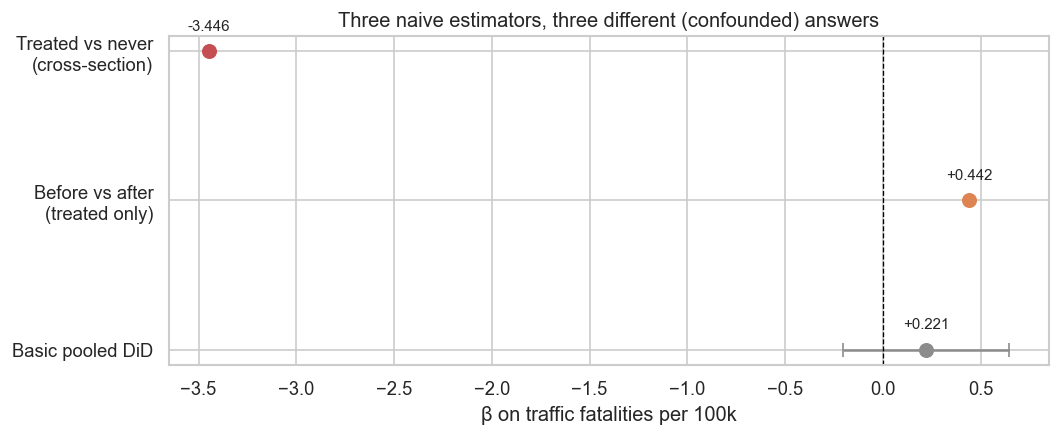

In [7]:
rows = [
    ("Treated vs never\n(cross-section)", m1.params["ever_treated"], None, "#C44E52"),
    ("Before vs after\n(treated only)",   m2.params["post"],        None, "#DD8452"),
    ("Basic pooled DiD",                   m3.params["did"],         m3.conf_int().loc["did"].values, "#8C8C8C"),
]
fig, ax = plt.subplots(figsize=(9, 3.8))
y = np.arange(len(rows))[::-1]
for yi,(lab,b,ci,col) in zip(y, rows):
    if ci is not None:
        ax.errorbar(b, yi, xerr=[[b-ci[0]],[ci[1]-b]], fmt="o", ms=8, capsize=4, color=col)
    else:
        ax.plot(b, yi, "o", ms=8, color=col)
    ax.text(b, yi+0.14, f"{b:+.3f}", ha="center", fontsize=9)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows])
ax.set_xlabel("β on traffic fatalities per 100k")
ax.set_title("Three naive estimators, three different (confounded) answers")
plt.tight_layout(); plt.savefig(OUT_DIR/"03_naive_ladder.png", bbox_inches="tight"); plt.show()

**Takeaway.** The cross-sectional contrast conflates *which* states legalize with the effect of legalizing; the before/after contrast conflates legalization with national trends; the pooled DiD is contaminated by staggered timing (early cohorts used as controls for late ones). All three motivate the design-based estimators in notebooks 04–05.